In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
from torch.optim import LBFGS, Adam
from tqdm import tqdm
import h5py

import os
import sys
current_dir = os.path.abspath('')
grandparent_dir = os.path.dirname(os.path.dirname(current_dir))
if grandparent_dir not in sys.path:
    sys.path.append(grandparent_dir)

from util import *

if not os.path.exists('results'):
    os.makedirs('results')

In [2]:
seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

device = 'cuda'

In [3]:
data = h5py.File('./square_cylinder_wake.mat', 'r')

time = data['T']['T'][()]

U = data['domain']['U'][()]
P = data['domain']['P'][()]
nodes = data['domain']['nodes'][()]
# vorticity
ω = data['domain']['w'][()]

data.close()

N = nodes.shape[0]
T = time.shape[0]


In [4]:

x, y, t, u, v, p = data_processing(nodes, time, U, P)


In [5]:

idx = np.random.choice(N*T,2500, replace=False)

x_train = x[idx,:]
y_train = y[idx,:]
t_train = t[idx,:]
u_train = u[idx,:]
v_train = v[idx,:]
p_train = p[idx,:]

x_train = torch.tensor(x_train, dtype=torch.float32, requires_grad=True).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32, requires_grad=True).to(device)
t_train = torch.tensor(t_train, dtype=torch.float32, requires_grad=True).to(device)
u_train = torch.tensor(u_train, dtype=torch.float32, requires_grad=True).to(device)
v_train = torch.tensor(v_train, dtype=torch.float32, requires_grad=True).to(device)
p_train = torch.tensor(p_train, dtype=torch.float32, requires_grad=True).to(device)


In [6]:
class PINNs(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layer):
        super(PINNs, self).__init__()

        layers = []
        for i in range(num_layer-1):
            if i == 0:
                layers.append(nn.Linear(in_features=in_dim, out_features=hidden_dim))
                layers.append(nn.Tanh())
            else:
                layers.append(nn.Linear(in_features=hidden_dim, out_features=hidden_dim))
                layers.append(nn.Tanh())

        layers.append(nn.Linear(in_features=hidden_dim, out_features=out_dim))

        self.linear = nn.Sequential(*layers)

    def forward(self, x, y, t):
        src = torch.cat((x,y,t), dim=-1)
        return self.linear(src)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight, gain=1.0 / np.sqrt(2.0))
        nn.init.zeros_(m.bias)

In [7]:
model = PINNs(in_dim=3, hidden_dim=512, out_dim=2, num_layer=4).to(device)
model.apply(init_weights)
optim = LBFGS(model.parameters(), line_search_fn='strong_wolfe')

print(model)
print(get_n_params(model))

PINNs(
  (linear): Sequential(
    (0): Linear(in_features=3, out_features=512, bias=True)
    (1): Tanh()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): Tanh()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): Tanh()
    (6): Linear(in_features=512, out_features=2, bias=True)
  )
)
528386


In [8]:
monitor_snap = 120
monitor_x_base = nodes[:, 0:1].reshape(-1, 1)
monitor_y_base = nodes[:, 1:2].reshape(-1, 1)
monitor_t_base = np.tile(time[monitor_snap], (N, 1)).reshape(-1, 1)
monitor_reference = U[monitor_snap, :, 0].reshape(-1, 1)
relative_l2_threshold = 0.1
monitor_reference = monitor_reference

def get_monitor_prediction():
    monitor_x = torch.tensor(monitor_x_base, dtype=torch.float32, device=device, requires_grad=True)
    monitor_y = torch.tensor(monitor_y_base, dtype=torch.float32, device=device, requires_grad=True)
    monitor_t = torch.tensor(monitor_t_base, dtype=torch.float32, device=device, requires_grad=True)
    monitor_psi = model(monitor_x, monitor_y, monitor_t)[:, 0:1]
    prediction = torch.autograd.grad(
        monitor_psi,
        monitor_y,
        grad_outputs=torch.ones_like(monitor_psi),
        retain_graph=True,
        create_graph=True,
    )[0]
    return prediction.detach().cpu().numpy().reshape(-1, 1)

convergence_tracker = RelativeL2ConvergenceTracker(
    monitor_reference,
    relative_l2_threshold,
)
convergence_tracker.record(0.0, get_monitor_prediction())


0.9996410747876283

In [9]:
time_recorder = ModelTimeRecorder(device)
loss_track = []

for i in tqdm(range(300)):
    def closure():
        psi_and_p = model(x_train, y_train, t_train)
        psi = psi_and_p[:,0:1]
        p_pred = psi_and_p[:,1:2]

        u_pred = torch.autograd.grad(psi, y_train, grad_outputs=torch.ones_like(psi), retain_graph=True, create_graph=True)[0]
        v_pred = - torch.autograd.grad(psi, x_train, grad_outputs=torch.ones_like(psi), retain_graph=True, create_graph=True)[0]

    
    
        u_t = torch.autograd.grad(u_pred, t_train, grad_outputs=torch.ones_like(u_pred), retain_graph=True, create_graph=True)[0]
        u_x = torch.autograd.grad(u_pred, x_train, grad_outputs=torch.ones_like(u_pred), retain_graph=True, create_graph=True)[0]
        u_y = torch.autograd.grad(u_pred, y_train, grad_outputs=torch.ones_like(u_pred), retain_graph=True, create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_train, grad_outputs=torch.ones_like(u_x), retain_graph=True, create_graph=True)[0]
        u_yy = torch.autograd.grad(u_y, y_train, grad_outputs=torch.ones_like(u_y), retain_graph=True, create_graph=True)[0]

        v_t = torch.autograd.grad(v_pred, t_train, grad_outputs=torch.ones_like(v_pred), retain_graph=True, create_graph=True)[0]
        v_x = torch.autograd.grad(v_pred, x_train, grad_outputs=torch.ones_like(v_pred), retain_graph=True, create_graph=True)[0]
        v_y = torch.autograd.grad(v_pred, y_train, grad_outputs=torch.ones_like(v_pred), retain_graph=True, create_graph=True)[0]
        v_xx = torch.autograd.grad(v_x, x_train, grad_outputs=torch.ones_like(v_x), retain_graph=True, create_graph=True)[0]
        v_yy = torch.autograd.grad(v_y, y_train, grad_outputs=torch.ones_like(v_y), retain_graph=True, create_graph=True)[0]

        p_x = torch.autograd.grad(p_pred, x_train, grad_outputs=torch.ones_like(p_pred), retain_graph=True, create_graph=True)[0]
        p_y = torch.autograd.grad(p_pred, y_train, grad_outputs=torch.ones_like(p_pred), retain_graph=True, create_graph=True)[0]


        f_u = u_t + u_pred*u_x + v_pred*u_y + p_x - 0.01*(u_xx + u_yy) 
        f_v = v_t + u_pred*v_x + v_pred*v_y + p_y - 0.01*(v_xx + v_yy)
    
        loss = (
            torch.mean(f_u**2) 
            + torch.mean(f_v**2) 
            + (torch.mean((u_pred-u_train)**2) 
            + torch.mean((v_pred-v_train)**2)
            + torch.mean((p_pred-p_train)**2))*100
        )
    
        loss_track.append(loss.item())
    
        optim.zero_grad()
        loss.backward()
        return loss

    with time_recorder.record_training():
        optim.step(closure)

    convergence_tracker.record(
        time_recorder.training_time,
        get_monitor_prediction(),
    )

100%|██████████| 300/300 [08:05<00:00,  1.62s/it]


In [10]:
np.save('./results/ns_square_loss_pinn.npy', loss_track)
torch.save(model.state_dict(), './results/ns_square_pinn.pt')

loss_track[-1]

print('Training Time: {:.2f} s'.format(time_recorder.training_time))

np.save(
    './results/ns_square_relative_l2_error_vs_training_time_pinns_u.npy',
    convergence_tracker.as_array(),
)
if convergence_tracker.first_threshold_time is None:
    print('Relative L2 threshold {:.3f} was not reached.'.format(relative_l2_threshold))
else:
    print(
        'Relative L2 threshold {:.3f} first reached at {:.6f} s'.format(
            relative_l2_threshold,
            convergence_tracker.first_threshold_time,
        )
    )


Training Time: 484.22 s
Relative L2 threshold 0.100 first reached at 200.511443 s


In [11]:
 # Test Data
snap = np.array([120])
x_test = nodes[:,0:1].reshape(-1,1)
y_test = nodes[:,1:2].reshape(-1,1)
t_test = np.tile(time[snap], (N,1)).reshape(-1,1)

u_test = U[snap,:,0].reshape(-1,1)
v_test = U[snap,:,1].reshape(-1,1)
p_test = P[snap].reshape(-1,1)

ω_test = ω[snap,:].reshape(-1,1)

x_test = torch.tensor(x_test, dtype=torch.float32, requires_grad=True).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32, requires_grad=True).to(device)
t_test = torch.tensor(t_test, dtype=torch.float32, requires_grad=True).to(device)

In [12]:
with time_recorder.record_inference():
    # with torch.no_grad():
    psi_and_p_test = model(x_test, y_test, t_test)
print('Inference Time: {:.6f} s'.format(time_recorder.inference_time))
psi_test = psi_and_p_test[:,0:1]
p_pred_test = psi_and_p_test[:,1:2]

u_pred_test = torch.autograd.grad(psi_test, y_test, grad_outputs=torch.ones_like(psi_test), retain_graph=True, create_graph=True)[0]
v_pred_test = - torch.autograd.grad(psi_test, x_test, grad_outputs=torch.ones_like(psi_test), retain_graph=True, create_graph=True)[0]

v_x_pred_test = torch.autograd.grad(v_pred_test, x_test, grad_outputs=torch.ones_like(v_pred_test), retain_graph=True, create_graph=True)[0]
u_y_pred_test = torch.autograd.grad(u_pred_test, y_test, grad_outputs=torch.ones_like(u_pred_test), retain_graph=True, create_graph=True)[0]
ω_pred_test = v_x_pred_test - u_y_pred_test

u_pred_test = u_pred_test.cpu().detach().numpy()
v_pred_test = v_pred_test.cpu().detach().numpy()
p_pred_test = p_pred_test.cpu().detach().numpy()
ω_pred_test = ω_pred_test.cpu().detach().numpy()

Inference Time: 0.001734 s


In [13]:
error_u_l1 = np.linalg.norm(u_test-u_pred_test,1)/np.linalg.norm(u_test,1)
error_v_l1 = np.linalg.norm(v_test-v_pred_test,1)/np.linalg.norm(v_test,1)
error_p_l1 = np.linalg.norm(p_test-p_pred_test,1)/np.linalg.norm(p_test,1)

error_u_l1, error_v_l1, error_p_l1

(0.054089731941940014, 0.32150012576930775, 0.6323266954628906)

In [14]:
error_u_l2 = np.linalg.norm(u_test-u_pred_test,2)/np.linalg.norm(u_test,2)
error_v_l2 = np.linalg.norm(v_test-v_pred_test,2)/np.linalg.norm(v_test,2)
error_p_l2 = np.linalg.norm(p_test-p_pred_test,2)/np.linalg.norm(p_test,2)

error_u_l2, error_v_l2, error_p_l2

(0.07146750706566689, 0.33733164200952415, 0.5846616417831988)

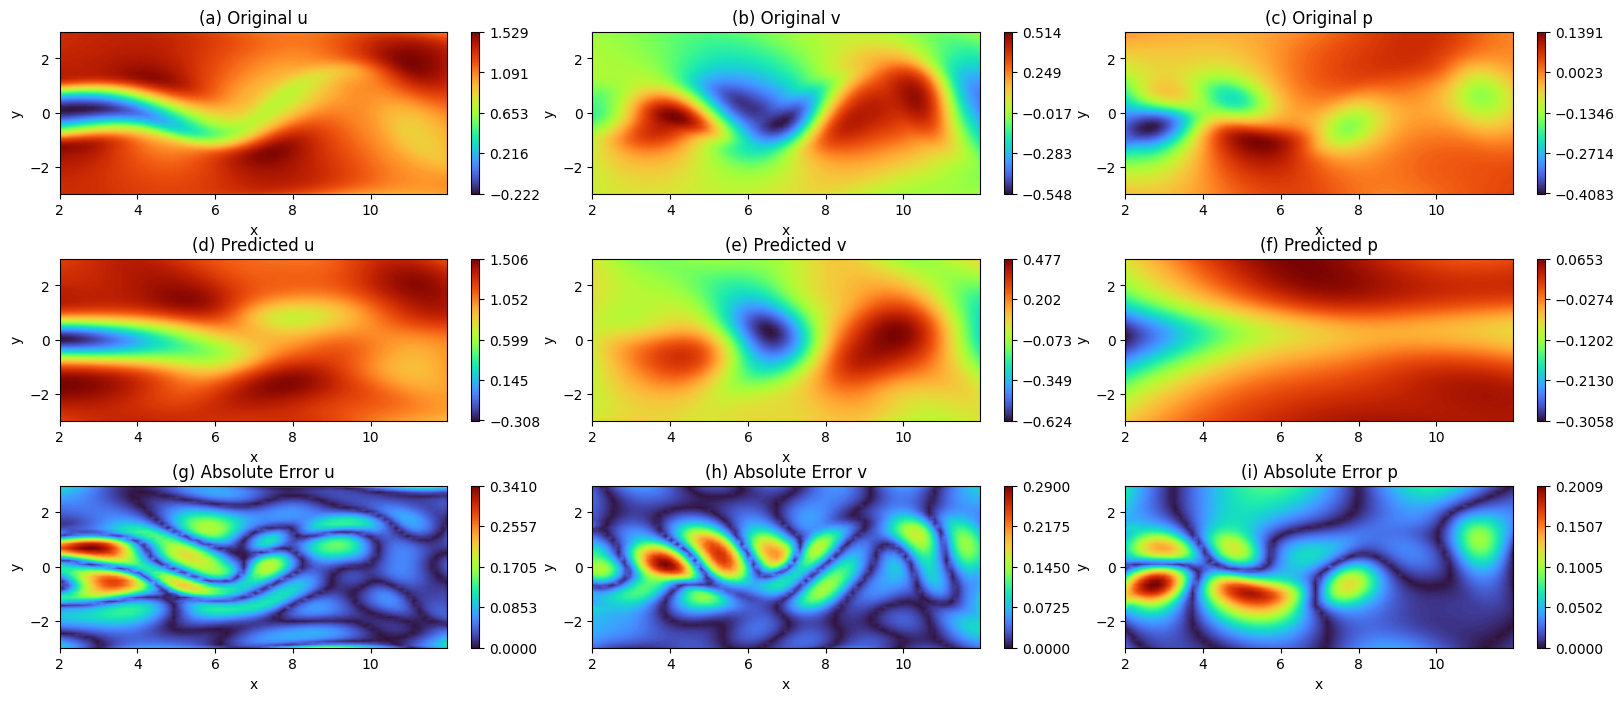

In [15]:
data_list = [u_test, v_test, p_test, u_pred_test, v_pred_test, p_pred_test, np.abs(u_pred_test - u_test), np.abs(v_pred_test - v_test), np.abs(p_pred_test - p_test)]

plt.figure(figsize=(20,8))
gs = plt.GridSpec(3, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1, 1], wspace=0.1, hspace=0.4)

for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i, j])
        contour = plt.tricontourf(x_test.cpu().detach().numpy().flatten(), y_test.cpu().detach().numpy().flatten(), data_list[i*3 + j].flatten(), levels=500, cmap='turbo')
        cbar = plt.colorbar(contour, ax=ax)
        cbar.set_ticks(np.linspace(data_list[i*3 + j].min(), data_list[i*3 + j].max(), num=5))
        plt.xlabel('x')
        plt.ylabel('y')
        if i == 0 and j == 0:
            plt.title(f'(a) Original u')
        elif i == 0 and j == 1:
            plt.title(f'(b) Original v')
        elif i == 0 and j == 2:
            plt.title(f'(c) Original p')
        elif i == 1 and j == 0:
            plt.title(f'(d) Predicted u')
        elif i == 1 and j == 1:
            plt.title(f'(e) Predicted v')
        elif i == 1 and j == 2:
            plt.title(f'(f) Predicted p')
        elif i == 2 and j == 0:
            plt.title(f'(g) Absolute Error u')
        elif i == 2 and j == 1:
            plt.title(f'(h) Absolute Error v')
        elif i == 2 and j == 2:
            plt.title(f'(i) Absolute Error p')

plt.savefig('./results/ns_square_pinn_uvp.png')
plt.show()

In [16]:
error_ω_l1 = np.linalg.norm(ω_test-ω_pred_test,1)/np.linalg.norm(ω_test,1)
error_ω_l2 = np.linalg.norm(ω_test-ω_pred_test,2)/np.linalg.norm(ω_test,2)

error_ω_l1, error_ω_l2

(0.6035706562009819, 0.5116826098682538)

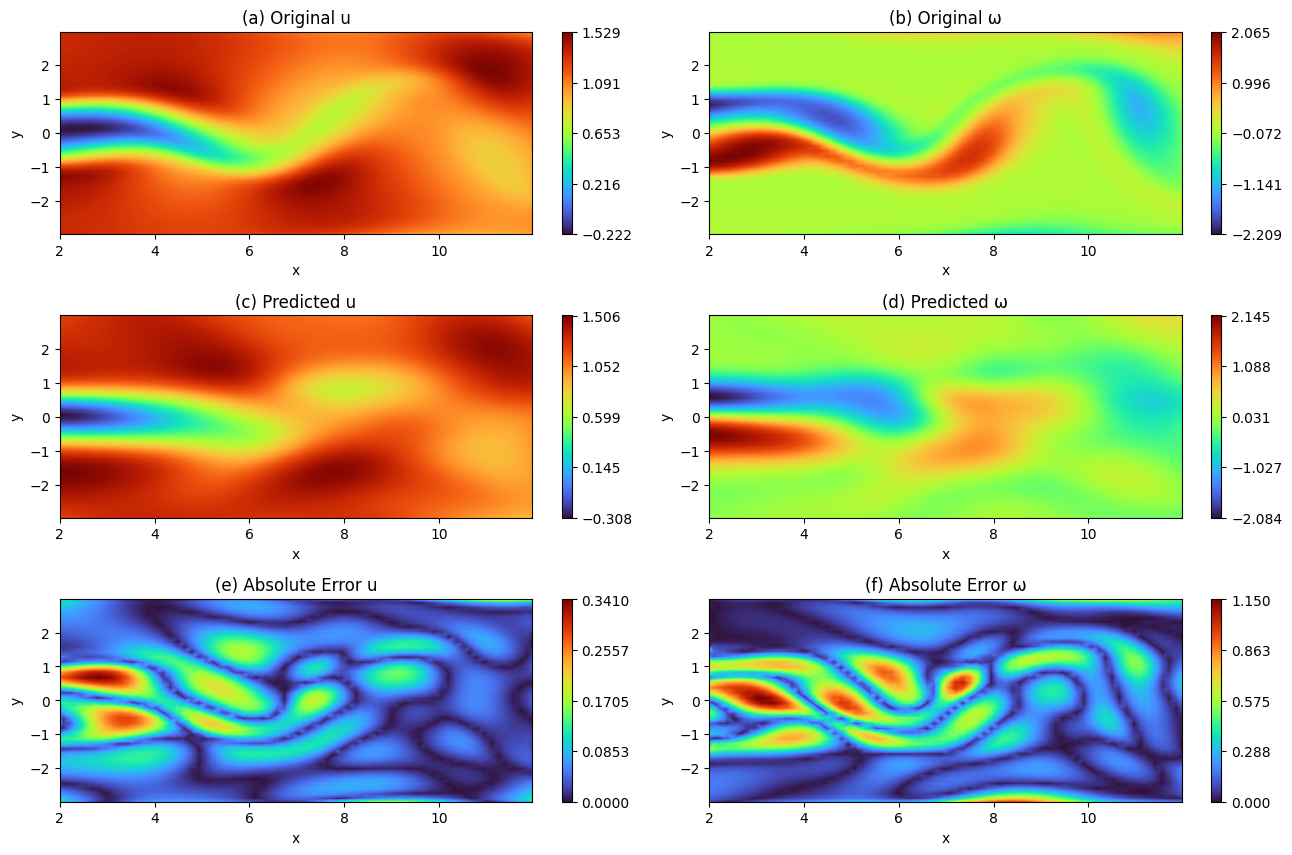

In [17]:
data_list = [u_test, ω_test, u_pred_test, ω_pred_test, np.abs(u_pred_test - u_test), np.abs(ω_pred_test - ω_test)]

plt.figure(figsize=(16,10))
gs = plt.GridSpec(3, 2, width_ratios=[1, 1], height_ratios=[1, 1, 1], wspace=0.1, hspace=0.4)

for i in range(3):
    for j in range(2):
        ax = plt.subplot(gs[i, j])
        contour = plt.tricontourf(x_test.cpu().detach().numpy().flatten(), y_test.cpu().detach().numpy().flatten(), data_list[i*2 + j].flatten(), levels=500, cmap='turbo')
        cbar = plt.colorbar(contour, ax=ax)
        cbar.set_ticks(np.linspace(data_list[i*2 + j].min(), data_list[i*2 + j].max(), num=5))
        plt.xlabel('x')
        plt.ylabel('y')
        if i == 0 and j == 0:
            plt.title(f'(a) Original u')
        elif i == 0 and j == 1:
            plt.title(f'(b) Original ω')
        elif i == 1 and j == 0:
            plt.title(f'(c) Predicted u')
        elif i == 1 and j == 1:
            plt.title(f'(d) Predicted ω')
        elif i == 2 and j == 0:
            plt.title(f'(e) Absolute Error u')
        elif i == 2 and j == 1:
            plt.title(f'(f) Absolute Error ω')

plt.savefig('./results/ns_square_pinn_u_omega.png')
plt.show()